In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision.models as models
from torch.onnx import export

import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from torch.nn.utils import parameters_to_vector
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch.optim.lr_scheduler import CosineAnnealingLR

In [3]:
# 乱数を一定にする
seed = 777  # 好きな数字でOK
torch.manual_seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
# onnxファイルを作成する関数
def model_to_onnx(model, output_file, input_shape = (1, 3, 224, 224)):
  model.eval()
  input_tensor = torch.randn(input_shape).to('cpu')
  input_names = ['input']
  output_names = ['output']
  torch.onnx.export(model, input_tensor, output_file, verbose = False, input_names = input_names, output_names = output_names)
  return output_file

In [5]:
# モデル読み込み
pt_model_path = "../dense.pt"
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 10)  # CIFAR-10 にあわせて出力層変更
model.load_state_dict(torch.load(pt_model_path))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
# 訓練データセット作成
transform = transforms.Compose([transforms.Resize(224),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])   # 正規化したほうがいいらしい

trainset = torchvision.datasets.CIFAR10(root = "./data", train = True, download = True, transform = transform)
trainloader = DataLoader(trainset, batch_size = 400, shuffle = True)

In [7]:
def project_l1_ball(tensor_x: np.ndarray, radius: float) -> np.ndarray:
    """
    テンソル `tensor_x` を、中心が原点のL1ノルム半径 `radius` の超球（L1ボール）の表面または内部に射影する。
    これは、制約条件 ||z||_1 <= radius を満たす、最も `tensor_x` に近い点 `z` を見つける操作。
    アルゴリズムは、"Projection onto the L1-ball" として知られる効率的な手法に基づいている。
    """
    # ステップ 1: 入力テンソルのL1ノルムを計算し、そもそも射影が必要かを確認
    # もしL1ノルムが既に半径以下なら、テンソルは制約を満たしており、何もしなくてよい。
    if np.sum(np.abs(tensor_x)) <= radius:
        return tensor_x

    # ステップ 3: 符号情報を無視し、絶対値のテンソルを作成
    # 射影アルゴリズムは、正の象限（すべての要素が非負）で動作し、最後に元の符号を復元する。
    u_tensor = np.abs(tensor_x)

    # ステップ 4: 絶対値テンソル `u_tensor` を降順にソートする。
    # このソートが、効率的なアルゴリズムの鍵となる。
    u_sorted = np.sort(u_tensor, axis=None)[::-1]
    n_features = len(u_sorted)

    # ステップ 5: ソートされたベクトルの累積和を計算する。
    # sv[i-1] は、u の中で最も大きい i 個の要素の和を表す。
    sv = np.cumsum(u_sorted)

    # ステップ 6: 射影の閾値 `theta` を見つけるための条件を満たす `rho` を探す。
    # ここがアルゴリズムの核心部分。
    # 数学的な導出により、射影後のベクトルは `y = sign(v) * max(abs(v) - theta, 0)` という形になることが分かっている。
    # この `y` のL1ノルムが `radius` に等しくなるような `theta` を見つけたい。
    # そのための条件が `u_sorted[i-1] > (sv[i-1] - radius) / i` であり、
    # この条件を満たす最大のインデックスが `rho` となる。
    
    # i = 1, 2, ..., n_features を生成
    arange_i = np.arange(1, n_features + 1)
    
    # 条件を満たすインデックスの候補を探す
    rho_candidates = np.where(u_sorted > (sv - radius) / arange_i)[0]
    
    # 候補の中から最大のインデックスをrhoとして採用する（0-basedから1-basedに変換するため+1）
    # 候補がない場合は、すべての要素が同じだけシフトされるケース
    rho = rho_candidates[-1] + 1 if len(rho_candidates) > 0 else n_features

    # ステップ 7: 決定した `rho` を使って、最終的なシフト量 `theta` を計算する。
    # thetaは、各要素から（絶対値の形で）引き算される値。
    theta = (sv[rho - 1] - radius) / rho

    # ステップ 8: ソフトしきい値処理（soft-thresholding）を実行して、射影を完了させる。
    # 1. 各要素の絶対値から `theta` を引く。
    # 2. 結果が負になった場合は0にする（`np.maximum(..., 0)`）。
    # 3. 元の符号 `sign(v)` を掛け合わせて、正しい象限に戻す。
    projected_tensor_x = np.sign(tensor_x) * np.maximum(np.abs(tensor_x) - theta, 0)

    # ステップ 9: 返す。
    return projected_tensor_x

def hard_threshold(tensor_x: np.ndarray, K0: int) -> np.ndarray:
    """
    テンソル `tensor_x` に対してハードしきい値処理を適用する。
    これは、制約条件 ||z||_0 <= K0 を満たす、最も `tensor_x` に近い点 `z` を見つける操作。
    簡単に言うと、テンソルの要素のうち、絶対値が大きい方から `K0` 個だけを残し、
    それ以外をすべて厳密に0にする。
    """
    # ステップ 1: そもそも処理が必要かを確認
    # もし残したい非ゼロ要素の数 `K0` が、テンソルの全要素数以上なら、
    # どの要素も0にする必要はないので、そのまま返す。
    if K0 >= tensor_x.size:
        return tensor_x
    
    # ステップ 3: 0にすべき要素を決定するための「しきい値」を見つける。
    # しきい値は、ベクトル `v` の絶対値を小さい順にソートしたとき、
    # 後ろから `K0` 番目（つまり、絶対値が `K0` 番目に大きい要素）の値となる。
    # 例: v=[10, -2, 5, -8], K0=2 の場合、abs(v)=[10, 2, 5, 8]。
    #    ソートすると [2, 5, 8, 10]。後ろから2番目は `8`。これがしきい値となる。
    # 同じ値の要素があった場合は非ゼロの要素がK0
    threshold = np.sort(np.abs(tensor_x), axis=None)[-(K0+1)]

    # ステップ 4: しきい値に基づいて、値を0にする。
    # 絶対値がこのしきい値より「小さい」すべての要素を0で上書きする。
    # 例: abs(v) < 8 となるのは `2` と `5`。対応する元の要素 `-2` と `5` が0になる。
    tensor_x[np.abs(tensor_x) <= threshold] = 0

    return tensor_x



In [8]:
def D_op_4d(tensor: np.ndarray) -> np.ndarray:
    """
    4階数テンソル (out_ch, in_ch, h, w) の4方向の差分を計算し、
    5階数テンソル (out_ch, in_ch, h, w, 4) として返す。
    """
    # dim=0 (出力チャネル方向)
    diff_dim0 = np.roll(tensor, -1, axis=0) - tensor
    # dim=1 (入力チャネル方向)
    diff_dim1 = np.roll(tensor, -1, axis=1) - tensor
    # dim=2 (縦方向)
    diff_dim2 = np.roll(tensor, -1, axis=2) - tensor
    # dim=3 (横方向)
    diff_dim3 = np.roll(tensor, -1, axis=3) - tensor
    
    # 最後の軸に4つの差分をスタックする
    return np.stack([diff_dim0, diff_dim1, diff_dim2, diff_dim3], axis=-1)

# 転置差分がどんな演算なのかいまいちわかってない
def DT_op_4d(stacked_tensor: np.ndarray) -> np.ndarray:
    """
    D_op_4dの転置演算。5階数テンソルを受け取り、4階数テンソルを返す。
    """
    # 各差分を取り出す
    d0 = stacked_tensor[..., 0]
    d1 = stacked_tensor[..., 1]
    d2 = stacked_tensor[..., 2]
    d3 = stacked_tensor[..., 3]

    # 各々の転置差分を計算し、合計する (D^T = -D_backward)
    term0 = np.roll(d0, 1, axis=0) - d0
    term1 = np.roll(d1, 1, axis=1) - d1
    term2 = np.roll(d2, 1, axis=2) - d2
    term3 = np.roll(d3, 1, axis=3) - d3
    
    return term0 + term1 + term2 + term3

In [9]:
from scipy.sparse.linalg import cg, LinearOperator # LinearOperatorをインポート

def solve_admm(
    w: np.ndarray, 
    D_op, 
    DT_op, 
    K1: float, 
    K0_ratio: float, 
    rho: float, 
    gamma: float,
    n_iter: int,
):
    # --- 初期化 ---
    # 全ての変数を float64 で厳密に初期化
    x  = w.copy().astype(np.float64)
    y = D_op(x).astype(np.float64)
    z = x.copy().astype(np.float64)
    u1 = np.zeros_like(y, dtype=np.float64)
    u2 = np.zeros_like(z, dtype=np.float64)
    K0 = int(K0_ratio * w.size)
    
    # テンソルの総要素数を計算 (LinearOperatorのshape定義のため)
    n_elements = w.size

    print(f"Tensor shape: {w.shape}, K1={K1}, K0={K0} ({K0_ratio*100:.1f}%)")

    # ★★★ ここからが大幅な変更点 ★★★

    # 1. matvec関数を定義 (入力と出力が1次元ベクトルであることを明示)
    def matvec_for_lo(p_flat: np.ndarray) -> np.ndarray:
        # 内部で型変換は行わず、入力の型を信頼する
        p = p_flat.reshape(w.shape)
        DTD_p = DT_op(D_op(p))
        result = rho * DTD_p + gamma * p + p
        return result.flatten()

    # 2. LinearOperatorを明示的に作成
    # これにより、shapeとdtypeをcg関数に正確に伝える
    A = LinearOperator(
        shape=(n_elements, n_elements), # 作用素は (N, N) の正方行列として振る舞う
        matvec=matvec_for_lo,
        dtype=np.float64               # 扱うデータ型は float64 であることを明記
    )

    # ★★★ 変更ここまで ★★★


    # --- ADMM反復ループ ---
    for i in range(n_iter):
        # 1. x の更新
        # v は float64 であることを確認済み
        v = w + rho * DT_op(y - u1) + gamma * (z - u2)
        
        # LinearOperatorオブジェクト A を直接cgに渡す
        x_flat, _ = cg(A, v.flatten(), x0=x.flatten())
        x = x_flat.reshape(w.shape)

        # 2. y の更新
        v_proj1 = D_op(x) + u1
        y = project_l1_ball(v_proj1, K1)

        # 3. z の更新
        v_proj2 = x + u2
        z = hard_threshold(v_proj2, K0)

        # 4. 双対変数 u1, u2 の更新
        u1 = u1 + D_op(x) - y
        u2 = u2 + x - z
        
        if i % 5 == 0:
            recon_error = np.linalg.norm(x - w) / np.linalg.norm(w)
            print(f"Iteration {i+1}/{n_iter}, Reconstruction Error: {recon_error:.4f}")

    return x

In [10]:
def Omega(delta):
    """
    4階テンソルdeltaの各次元に沿った差分を計算し、
    その絶対値の総和を返す。
    """
    h = 1.0  # Dのパラメータ

    # 4つの次元それぞれに対して差分（勾配）を計算

    # dim=0 (出力チャネル方向の差分)
    diff_dim0 = delta[1:, :, :, :] - delta[:-1, :, :, :]

    # dim=1 (入力チャネル方向の差分)
    diff_dim1 = delta[:, 1:, :, :] - delta[:, :-1, :, :]

    # dim=2 (縦方向の差分)
    # 1行目から最後までと、0行目から最後の一つ手前までの差
    diff_dim2 = delta[:, :, 1:, :] - delta[:, :, :-1, :]

    # dim=3 (横方向の差分)
    # 1列目から最後までと、0列目から最後の一つ手前までの差
    diff_dim3 = delta[:, :, :, 1:] - delta[:, :, :, :-1]

    # 全ての差分の絶対値の総和を計算
    # これがD@deltaに相当する操作のL1ノルムになる
    constrain = torch.sum(torch.abs(diff_dim0)) + torch.sum(torch.abs(diff_dim1)) + torch.sum(torch.abs(diff_dim2)) + torch.sum(torch.abs(diff_dim3))

    return constrain / h

In [11]:
# 各層のTVを見てみる
layer_tvs = {}
layer_relative_tvs = {}
conv_layer_names = []

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        w_tensor = module.weight.detach().clone().to(device)
        tv = Omega(w_tensor).item()
        ave_tv = tv/(w_tensor).numel()
        relative_tv = tv / torch.sum(torch.abs(w_tensor)).item()
        layer_tvs[name] = tv
        layer_relative_tvs[name] = relative_tv
        conv_layer_names.append(name)
        print(f"{name}：TV={tv:.4f}     ave_TV={ave_tv:.4f}     relative_TV={relative_tv:.4f}")

conv1：TV=2785.1948     ave_TV=0.2960     relative_TV=3.8864
layer1.0.conv1：TV=5368.6899     ave_TV=0.1456     relative_TV=4.6001
layer1.0.conv2：TV=5110.8359     ave_TV=0.1386     relative_TV=4.3279
layer1.1.conv1：TV=5665.4883     ave_TV=0.1537     relative_TV=4.4829
layer1.1.conv2：TV=5081.4331     ave_TV=0.1378     relative_TV=4.3692
layer2.0.conv1：TV=9606.8564     ave_TV=0.1303     relative_TV=4.4254
layer2.0.conv2：TV=15700.7480     ave_TV=0.1065     relative_TV=4.4383
layer2.0.downsample.0：TV=1077.2024     ave_TV=0.1315     relative_TV=2.9591
layer2.1.conv1：TV=16048.6338     ave_TV=0.1088     relative_TV=4.4778
layer2.1.conv2：TV=14007.5215     ave_TV=0.0950     relative_TV=4.2592
layer3.0.conv1：TV=24442.1191     ave_TV=0.0829     relative_TV=3.9467
layer3.0.conv2：TV=45506.3359     ave_TV=0.0772     relative_TV=4.1868
layer3.0.downsample.0：TV=2261.6729     ave_TV=0.0690     relative_TV=2.8949
layer3.1.conv1：TV=41485.1523     ave_TV=0.0703     relative_TV=4.2055
layer3.1.conv2：TV=37498

In [12]:
import json

# JSONファイルから辞書を読み込む
with open('../その他/99cut_data.json', 'r') as f:
    zero_ratings = json.load(f)

with open('../その他/99cut_TV.json', 'r') as f:
    target_TVs = json.load(f)


In [13]:
#final_weights_to_assign = {}
masks = {}

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        print(f"\n--- レイヤー '{name}' の処理を開始 ---")

        # wを4階テンソルのまま取得
        # .detach().clone()で勾配情報を切り離し、安全なコピーを作成し、numpyに変換、scipyのcg法に合うようにfloat64に
        w_numpy = module.weight.detach().clone().to('cpu').numpy().astype(np.float64)

        # --- パラメータ設定と実行 ---
        K1_val = target_TVs[name]*0.5  #0.9     # Total Variationの上限
        K0_ratio_val = 1 - zero_ratings[name]   # 10%を非ゼロにする (目標のスパース率90%)
        rho_val = 0.01        # block性ペナルティパラメータ
        gamma_val = 15.0   # sparse性ペナルティパラメータ
        iterations = 300 #300   # 繰り返し回数

        # ADMMソルバーを実行
        x_final = solve_admm(
            w=w_numpy,
            D_op=D_op_4d,        
            DT_op=DT_op_4d,      
            K1=K1_val,
            K0_ratio=K0_ratio_val,
            rho=rho_val,
            gamma=gamma_val,
            n_iter=iterations
        )
        with torch.no_grad():
            # 閾値で0に近い値を完全な0にする
            x_final[np.abs(x_final) <= 1e-4] = 0
            # モデルを上書き
            module.weight.copy_(torch.tensor(x_final))

        # 結果の簡単な確認
        print("\n結果:")
        #print(x_final)
        print(f"元の重みテンソルの非ゼロの要素数: {np.sum(w_numpy != 0)}")
        print(f"ADMM後の重みテンソルの非ゼロの要素数: {np.sum(x_final != 0)} (目標数{int(K0_ratio_val * w_numpy.size)})")
        print(f"||Dx||_1: {np.sum(np.abs(D_op_4d(x_final))):.4f} (制約は{K1_val}以下)")



--- レイヤー 'conv1' の処理を開始 ---
Tensor shape: (64, 3, 7, 7), K1=1246.541015625, K0=3307 (35.2%)
Iteration 1/300, Reconstruction Error: 0.0000
Iteration 6/300, Reconstruction Error: 0.1778
Iteration 11/300, Reconstruction Error: 0.1891
Iteration 16/300, Reconstruction Error: 0.2160
Iteration 21/300, Reconstruction Error: 0.2559
Iteration 26/300, Reconstruction Error: 0.3022


Iteration 31/300, Reconstruction Error: 0.3478
Iteration 36/300, Reconstruction Error: 0.3880
Iteration 41/300, Reconstruction Error: 0.4214
Iteration 46/300, Reconstruction Error: 0.4482
Iteration 51/300, Reconstruction Error: 0.4683
Iteration 56/300, Reconstruction Error: 0.4825
Iteration 61/300, Reconstruction Error: 0.4917
Iteration 66/300, Reconstruction Error: 0.4972
Iteration 71/300, Reconstruction Error: 0.5003


Iteration 76/300, Reconstruction Error: 0.5015
Iteration 81/300, Reconstruction Error: 0.5017
Iteration 86/300, Reconstruction Error: 0.5013
Iteration 91/300, Reconstruction Error: 0.5005
Iteration 96/300, Reconstruction Error: 0.4997
Iteration 101/300, Reconstruction Error: 0.4988
Iteration 106/300, Reconstruction Error: 0.4977


Iteration 111/300, Reconstruction Error: 0.4966
Iteration 116/300, Reconstruction Error: 0.4958
Iteration 121/300, Reconstruction Error: 0.4951
Iteration 126/300, Reconstruction Error: 0.4946
Iteration 131/300, Reconstruction Error: 0.4943
Iteration 136/300, Reconstruction Error: 0.4942
Iteration 141/300, Reconstruction Error: 0.4942
Iteration 146/300, Reconstruction Error: 0.4944
Iteration 151/300, Reconstruction Error: 0.4946
Iteration 156/300, Reconstruction Error: 0.4948


Iteration 161/300, Reconstruction Error: 0.4950
Iteration 166/300, Reconstruction Error: 0.4954
Iteration 171/300, Reconstruction Error: 0.4958
Iteration 176/300, Reconstruction Error: 0.4961
Iteration 181/300, Reconstruction Error: 0.4965
Iteration 186/300, Reconstruction Error: 0.4968
Iteration 191/300, Reconstruction Error: 0.4970
Iteration 196/300, Reconstruction Error: 0.4973


...

Iteration 281/300, Reconstruction Error: 0.9863


Iteration 286/300, Reconstruction Error: 0.9863


Iteration 291/300, Reconstruction Error: 0.9863


Iteration 296/300, Reconstruction Error: 0.9863



結果:
元の重みテンソルの非ゼロの要素数: 2359296
ADMM後の重みテンソルの非ゼロの要素数: 1875 (目標数1875)
||Dx||_1: 389.7130 (制約は389.68109130859375以下)


In [14]:
# 非構造時のゼロ比率を表示
all_conv_params = 0
all_conv_zeros = 0
layer_params = {}

for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    print(f"{name} Zero-Ratio: {100.0 * float(torch.sum(module.weight == 0)) / float(module.weight.nelement()):.4f}%")
    weight_after_pruning = module.weight
    layer_params[name] = module.weight.numel()
    num_zeros = (weight_after_pruning == 0).sum().item()
    total_params = weight_after_pruning.numel()
    all_conv_params += total_params
    all_conv_zeros += num_zeros

sparsity = 100. * all_conv_zeros / all_conv_params if all_conv_params > 0 else 0
print(f"全畳み込み層の0率：{sparsity:.4f}%")

save_all_conv_params = all_conv_params

conv1 Zero-Ratio: 64.7640%
layer1.0.conv1 Zero-Ratio: 87.6736%
layer1.0.conv2 Zero-Ratio: 88.2433%


layer1.1.conv1 Zero-Ratio: 87.1636%
layer1.1.conv2 Zero-Ratio: 88.8428%


layer2.0.conv1 Zero-Ratio: 90.2100%
layer2.0.conv2 Zero-Ratio: 94.5692%
layer2.0.downsample.0 Zero-Ratio: 80.9204%
layer2.1.conv1 Zero-Ratio: 94.4546%


layer2.1.conv2 Zero-Ratio: 96.1941%
layer3.0.conv1 Zero-Ratio: 96.6485%


layer3.0.conv2 Zero-Ratio: 98.0452%
layer3.0.downsample.0 Zero-Ratio: 94.8669%
layer3.1.conv1 Zero-Ratio: 98.7701%
layer3.1.conv2 Zero-Ratio: 99.1913%
layer4.0.conv1 Zero-Ratio: 99.4364%


layer4.0.conv2 Zero-Ratio: 99.7595%
layer4.0.downsample.0 Zero-Ratio: 95.1149%


layer4.1.conv1 Zero-Ratio: 99.8160%
layer4.1.conv2 Zero-Ratio: 99.9205%
全畳み込み層の0率：98.9999%


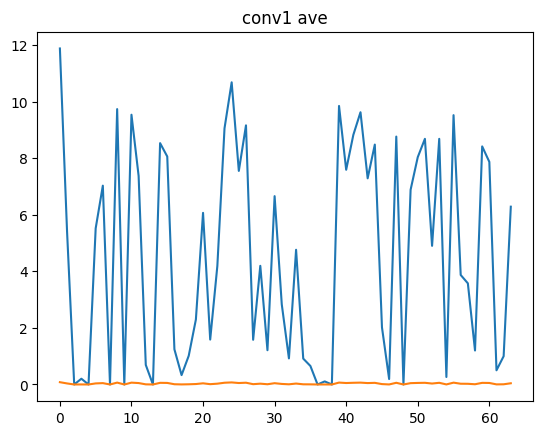

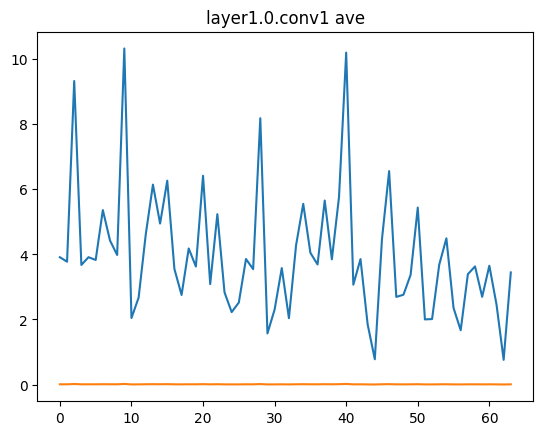

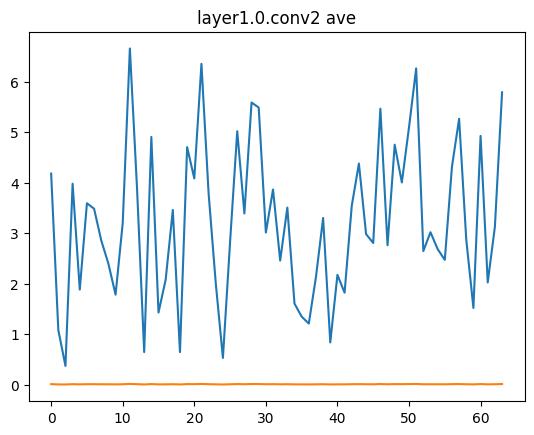

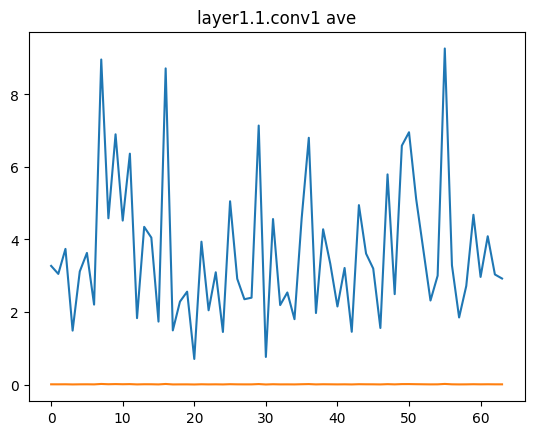

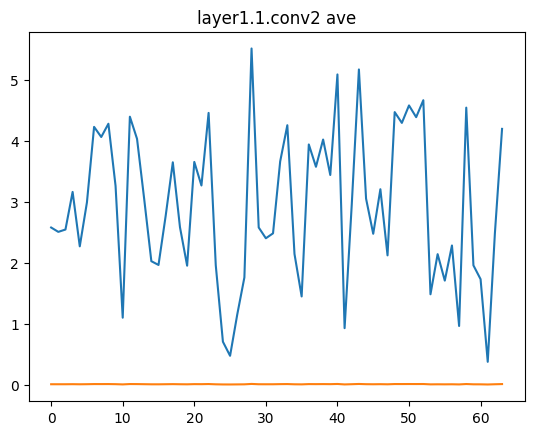

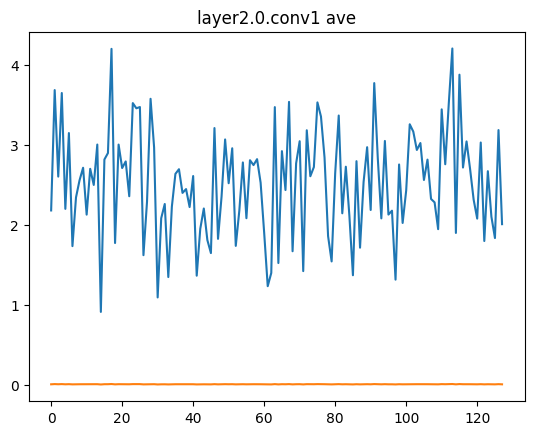

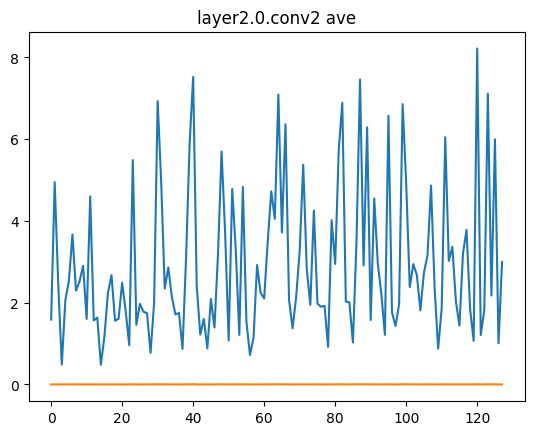

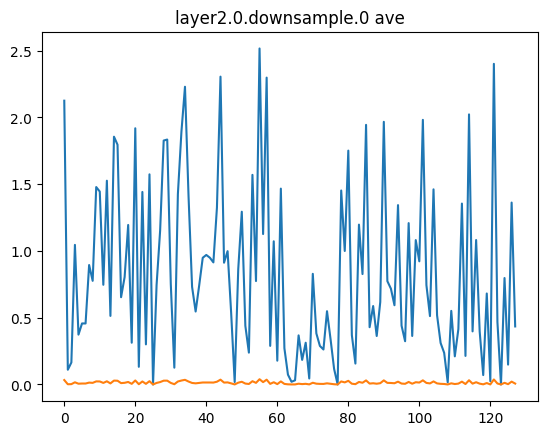

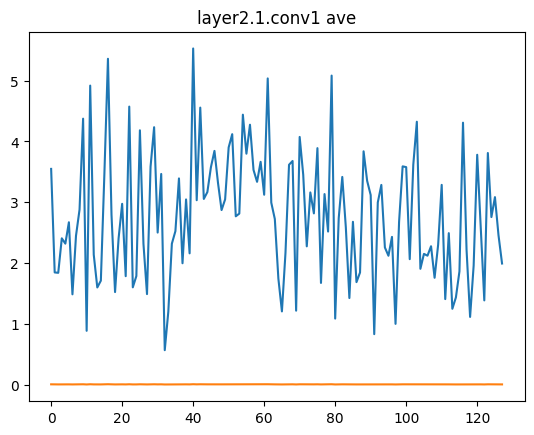

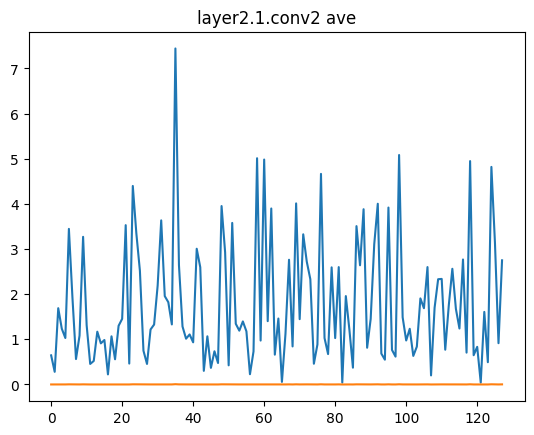

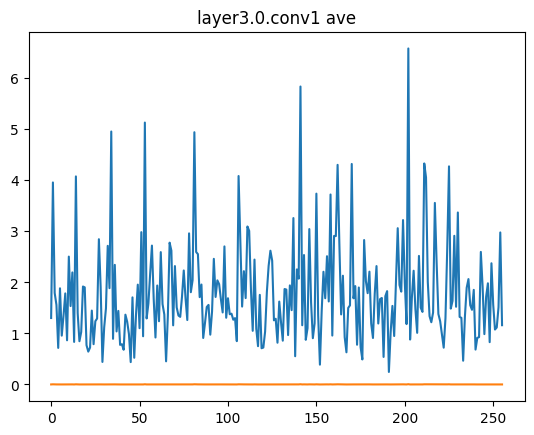

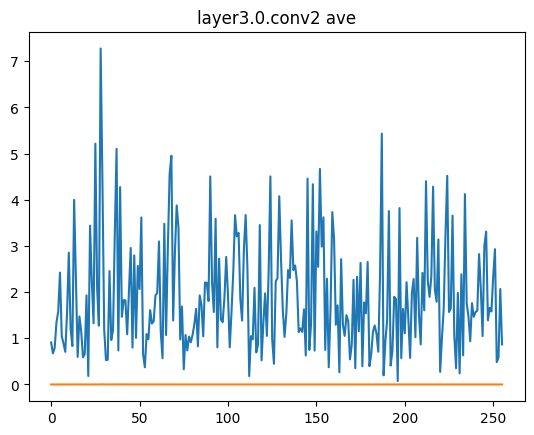

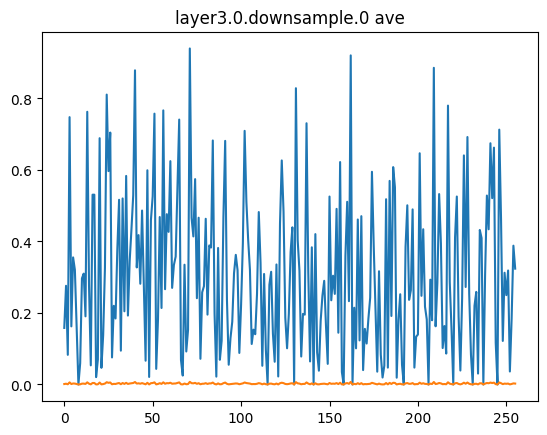

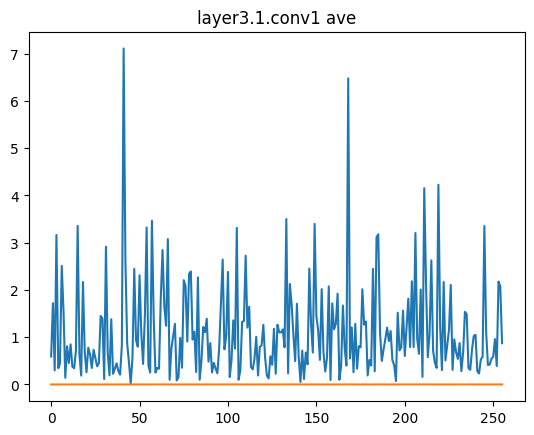

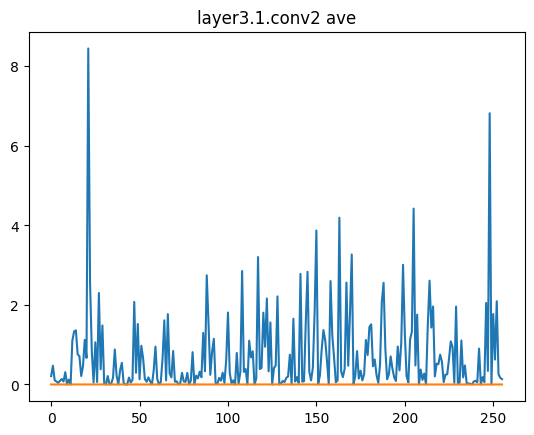

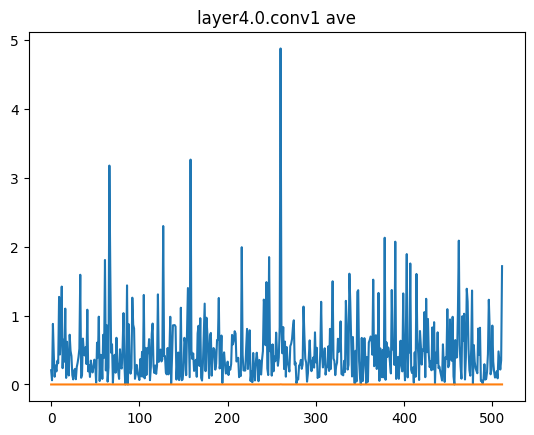

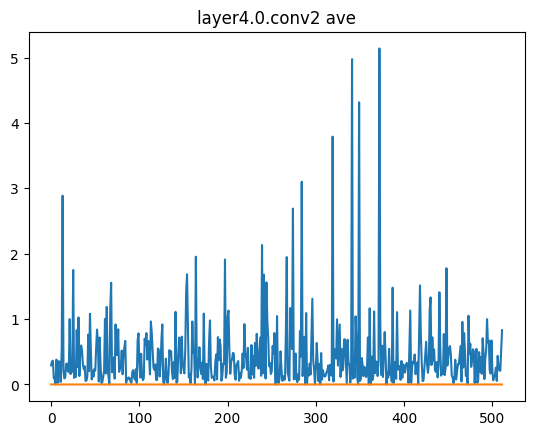

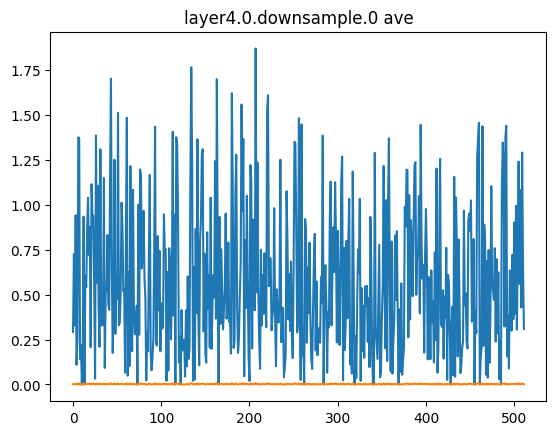

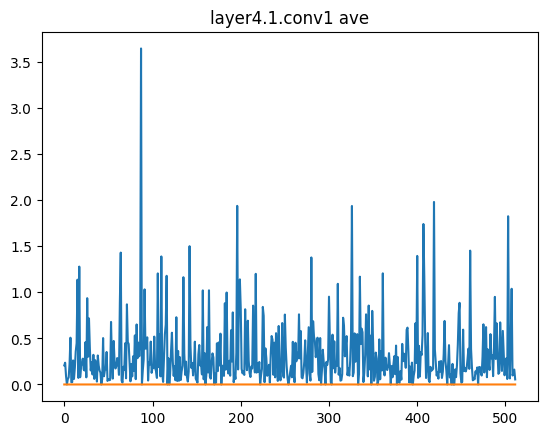

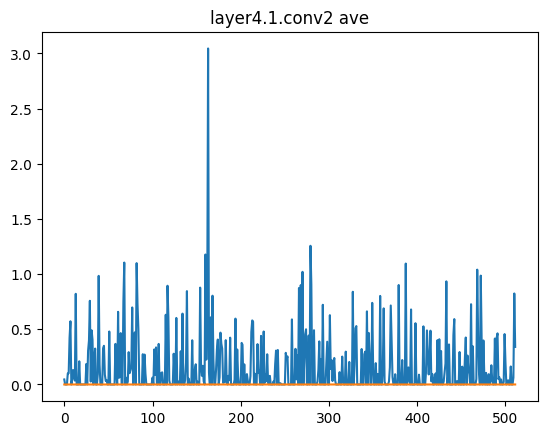

In [15]:
# フィルターごとの重み合計や平均を見る
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        # 重みテンソルを取得 (out_channels, in_channels, h, w)
        weight = module.weight.detach()
        
        # フィルター（out_channels次元）ごとに、絶対値の合計を計算
        # dim=(1,2,3) は in_channels, height, width の次元を潰すという意味
        filter_sum = torch.sum(torch.abs(weight), dim=(1, 2, 3))
        filter_ave = filter_sum / (weight.size()[1]*weight.size()[2]*weight.size()[3])

        plt.plot(filter_sum)
        #plt.ylim(-0.1, 0.2)
        plt.title(name+" sum")
        #plt.show()
        plt.plot(filter_ave)
        plt.title(name+" ave")
        #plt.ylim(-0, 0.01)
        plt.show()

In [16]:
import torch_pruning as tp
#print(tp.__version__)
#print(tp.__file__)

# 準備ができたモデルをGPU/CPUに送る
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


####### ADMM後のモデルを用いて枝刈りターゲットを特定

# 枝刈りしたいモジュール名と、その中で削除するチャネルのインデックスを保存する辞書
pruning_targets_by_name = {}

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        # 重みテンソルを取得 (out_channels, in_channels, h, w)
        weight = module.weight.detach()
        
        # フィルター（out_channels次元）ごとに、絶対値の合計を計算
        # dim=(1,2,3) は in_channels, height, width の次元を潰すという意味
        filter_sum = torch.sum(torch.abs(weight), dim=(1, 2, 3))
        filter_ave = filter_sum / (weight.size()[1]*weight.size()[2]*weight.size()[3])
        
        # 合計が0のフィルター（＝全ての重みが0のフィルター）のインデックスを見つける
        indices_to_prune = torch.where((filter_sum <= 0.5) & (filter_ave<=0.005))[0].tolist()  # filter_sum == 0
        
        # 刈るべきフィルターが1つでもあれば、辞書に記録
        if indices_to_prune:
            pruning_targets_by_name[name] = indices_to_prune
            print(f"レイヤー '{name}': {len(indices_to_prune)}個のフィルターを枝刈り対象として特定。")

#######


レイヤー 'conv1': 13個のフィルターを枝刈り対象として特定。
レイヤー 'layer1.0.conv2': 1個のフィルターを枝刈り対象として特定。
レイヤー 'layer1.1.conv2': 2個のフィルターを枝刈り対象として特定。
レイヤー 'layer2.0.conv2': 2個のフィルターを枝刈り対象として特定。
レイヤー 'layer2.0.downsample.0': 32個のフィルターを枝刈り対象として特定。
レイヤー 'layer2.1.conv2': 17個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.0.conv1': 7個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.0.conv2': 17個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.0.downsample.0': 205個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.1.conv1': 80個のフィルターを枝刈り対象として特定。
レイヤー 'layer3.1.conv2': 158個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.0.conv1': 338個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.0.conv2': 363個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.0.downsample.0': 261個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.1.conv1': 412個のフィルターを枝刈り対象として特定。
レイヤー 'layer4.1.conv2': 458個のフィルターを枝刈り対象として特定。


In [17]:
####### 密モデルに対して枝刈り計画を作成し、実行

# 密モデルの重みに対してマスクをかける
pt_model_path = "../dense.pt"
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 10)  # CIFAR-10 にあわせて出力層変更
model.load_state_dict(torch.load(pt_model_path))
model.to(device)

# 依存関係グラフを構築するためのダミー入力
# 値はランダムでOK。形状が正しいことが重要。
example_inputs = torch.randn(1, 3, 224, 224).to(device)

# ★★★ ここからが、より堅牢なワークフロー ★★★

# 1. 依存関係グラフを構築 (これは変更なし)
DG = tp.DependencyGraph()
DG.build_dependency(model, example_inputs=example_inputs)

# 2. 枝刈りグループのリストを作成する
pruning_groups = []
for name, indices in pruning_targets_by_name.items():
    # ターゲットのモジュールを取得
    module_to_prune = model.get_submodule(name)
    
    # 3. DG.get_pruning_groupを使って、依存関係を明示的に解決させる
    #    このグループには、conv1だけでなく、bn1なども自動的に含まれる
    group = DG.get_pruning_group(
        module=module_to_prune, 
        pruning_fn=tp.function.prune_conv_out_channels,  
        idxs=indices
    )
    pruning_groups.append(group)
    print(f"レイヤー '{name}' の枝刈りグループを作成: {group}")

# 4. グループを一つずつ実行する
for group in pruning_groups:
    # 念のため、グループが有効かチェック
    if DG.check_pruning_group(group):
        group.prune()


レイヤー 'conv1' の枝刈りグループを作成: 
--------------------------------
          Pruning Group
--------------------------------
[0] prune_out_channels on conv1 (Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)) => prune_out_channels on conv1 (Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)), len(idxs)=13
[1] prune_out_channels on conv1 (Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)) => prune_out_channels on bn1 (BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)), len(idxs)=13
[2] prune_out_channels on bn1 (BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)) => prune_out_channels on _ElementWiseOp_20(ReluBackward0), len(idxs)=13
[3] prune_out_channels on _ElementWiseOp_20(ReluBackward0) => prune_out_channels on _ElementWiseOp_19(MaxPool2DWithIndicesBackward0), len(idxs)=13
[4] prune_out_channels on _ElementWiseOp_19(MaxPool2DWithIndicesBackward0) => pru

In [18]:
# 構造的枝刈りしたときのゼロ比率を表示
all_conv_params = 0
all_conv_zeros = 0

for name, module in model.named_modules():
  if isinstance(module, torch.nn.Conv2d):
    before_weight =layer_params[name]
    print(f"{name} Zero-Ratio: {100.0 * (1 - float(module.weight.nelement()) / float(before_weight)):.4f}%")
    weight_after_pruning = module.weight
    num_zeros = (weight_after_pruning == 0).sum().item()
    total_params = weight_after_pruning.numel()
    all_conv_params += total_params
    all_conv_zeros += num_zeros

sparsity = 100. * all_conv_zeros / all_conv_params if all_conv_params > 0 else 0
print(f"全畳み込み層の0率：{sparsity:.4f}%")

print(f"元のサイズのモデルから見た全畳み込み層の0率：{(1 - all_conv_params / save_all_conv_params)*100}")

print(model)

conv1 Zero-Ratio: 23.4375%
layer1.0.conv1 Zero-Ratio: 23.4375%
layer1.0.conv2 Zero-Ratio: 23.4375%
layer1.1.conv1 Zero-Ratio: 23.4375%
layer1.1.conv2 Zero-Ratio: 23.4375%
layer2.0.conv1 Zero-Ratio: 23.4375%
layer2.0.conv2 Zero-Ratio: 37.5000%
layer2.0.downsample.0 Zero-Ratio: 52.1484%
layer2.1.conv1 Zero-Ratio: 37.5000%
layer2.1.conv2 Zero-Ratio: 37.5000%
layer3.0.conv1 Zero-Ratio: 39.2090%
layer3.0.conv2 Zero-Ratio: 82.5226%
layer3.0.downsample.0 Zero-Ratio: 88.7695%
layer3.1.conv1 Zero-Ratio: 87.6465%
layer3.1.conv2 Zero-Ratio: 87.6465%
layer4.0.conv1 Zero-Ratio: 93.8934%
layer4.0.conv2 Zero-Ratio: 90.1100%
layer4.0.downsample.0 Zero-Ratio: 94.7708%
layer4.1.conv1 Zero-Ratio: 94.3161%
layer4.1.conv2 Zero-Ratio: 94.3161%
全畳み込み層の0率：0.0000%
元のサイズのモデルから見た全畳み込み層の0率：86.84376665635047
ResNet(
  (conv1): Conv2d(3, 48, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=T

In [19]:
# 再訓練
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)   #lr = 0.001で損失0.02とか
num_epochs = 30 #15
epoch_loss_list = []
# CosineAnnealingLRを定義
# T_max: 学習率が半周期で最小値になるまでのエポック数。通常、総エポック数を指定。
# eta_min: 最小学習率。
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0)

for epoch in range(num_epochs):
  model.train()
  model = model.to(device)
  total_loss = 0.0
  num_train = 0
  for inputs, labels in trainloader:
    inputs, labels = inputs.to(device), labels.to(device)   # データ代入

    # 重み更新のための手順
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # 損失を記録
    total_loss += loss.item()*labels.size(0)
    num_train+=labels.size(0)

  # 出力と記録
  epoch_loss_list.append(total_loss/num_train)
  current_lr = optimizer.param_groups[0]['lr']
  print(f'Epoch[{epoch+1}/{num_epochs}], Loss: {epoch_loss_list[epoch]:.4f}, LR: {current_lr:.8f}')


  # 次のエポックへの準備
  if epoch >= 1:
    if np.abs(epoch_loss_list[epoch]-epoch_loss_list[epoch-1]) < 0.001:
      print('early stop')
      break
  scheduler.step()

Epoch[1/30], Loss: 0.7258, LR: 0.00100000


Epoch[2/30], Loss: 0.3530, LR: 0.00099726


Epoch[3/30], Loss: 0.2392, LR: 0.00098907


Epoch[4/30], Loss: 0.1674, LR: 0.00097553


Epoch[5/30], Loss: 0.1233, LR: 0.00095677


...

Epoch[9/30], Loss: 0.0330, LR: 0.00083457


Epoch[10/30], Loss: 0.0163, LR: 0.00079389


Epoch[11/30], Loss: 0.0083, LR: 0.00075000


Epoch[12/30], Loss: 0.0054, LR: 0.00070337


Epoch[13/30], Loss: 0.0053, LR: 0.00065451
early stop


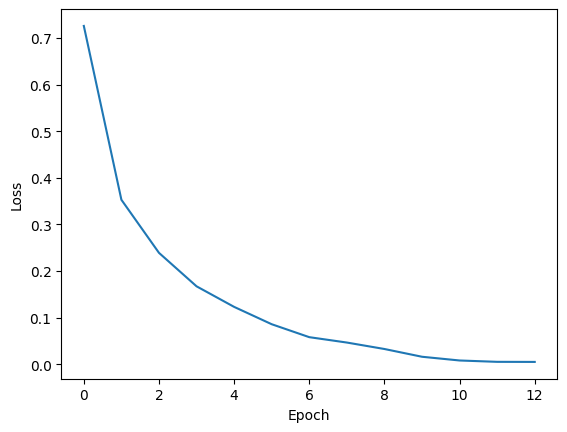

In [20]:
# 損失グラフ作成
plt.plot(epoch_loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [21]:
# onnxファイルとptファイルの作成
model = model.to('cpu')
model_to_onnx(model, "ADMM_onlyFilterPruning.onnx")
torch.save(model.state_dict(), "ADMM_onlyFilterPruning.pt")

In [22]:
# 評価関数 (正解率を返すように変更)
def accuracy_test(model, test_loader, device):
    model.eval()
    model = model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'正解率: {accuracy:.2f}%')
    return accuracy

from deepsparse.benchmark.benchmark_model import benchmark_model
# 推論速度ベンチマーク (速度を返すように変更)
def run_benchmark(model_path, batch_size):
    result = benchmark_model(model_path, batch_size=batch_size)
    stats = result["benchmark_result"]
    median_time = stats["median"]
    print(f"推論レイテンシ中央値: {median_time:.2f} ms")
    return median_time

/home/rkaneko/.conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-01-10 18:14:28.264476705 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [23]:
import time

testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=400, shuffle=False)

start_time = time.time()
accuracy_test(model, testloader, device)
print(f"testloaderをバッチサイズ400で分けた時のGPUによる全推論が終わるまでの時間：{time.time()-start_time:.4f} sec")
run_benchmark("ADMM_onlyFilterPruning.onnx", batch_size=400)

2026-01-10 18:14:42 deepsparse.benchmark.helpers INFO     Thread pinning to cores enabled


正解率: 90.41%
testloaderをバッチサイズ400で分けた時のGPUによる全推論が終わるまでの時間：13.0141 sec


DeepSparse, Copyright 2021-present / Neuralmagic, Inc. version: 1.8.0 COMMUNITY | (e3778e93) (release) (optimized) (system=avx512, binary=avx512)


2026-01-10 18:14:43 deepsparse.benchmark.benchmark_model INFO     deepsparse.engine.Engine:
	onnx_file_path: ADMM_onlyFilterPruning.onnx
	batch_size: 400
	num_cores: 4
	num_streams: 1
	scheduler: Scheduler.default
	fraction_of_supported_ops: 1.0
	cpu_avx_type: avx512
	cpu_vnni: False


2026-01-10 18:14:43 deepsparse.utils.onnx INFO     Generating input 'input', type = float32, shape = [400, 3, 224, 224]


2026-01-10 18:14:43 deepsparse.benchmark.benchmark_model INFO     Starting 'singlestream' performance measurements for 10 seconds


推論レイテンシ中央値: 769.36 ms


769.3580007180572

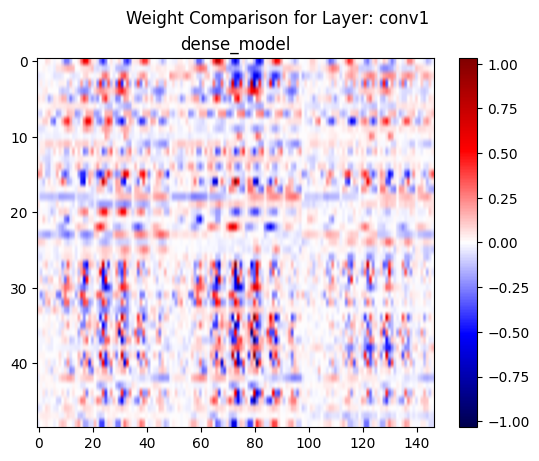

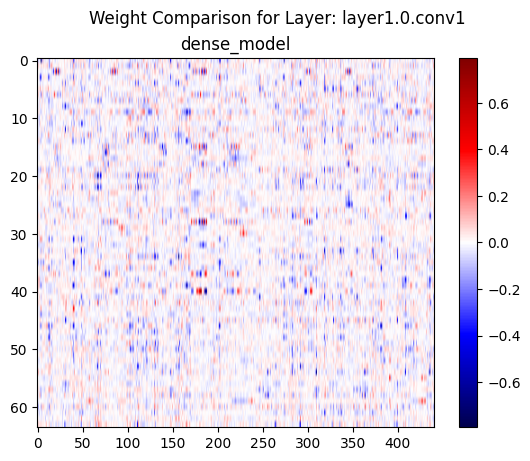

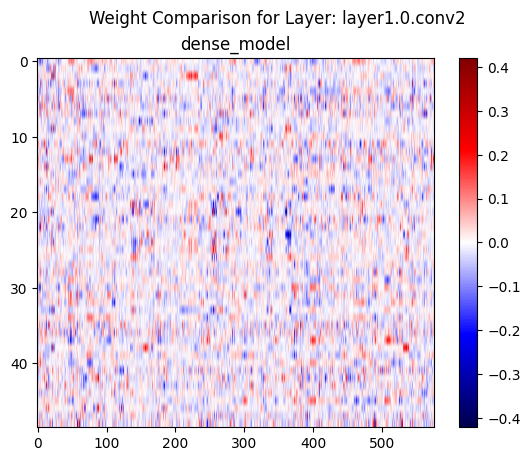

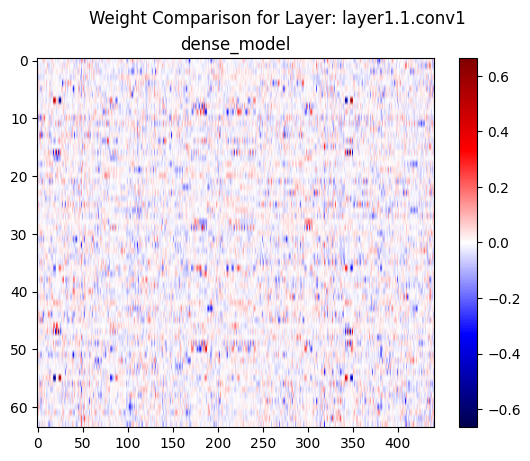

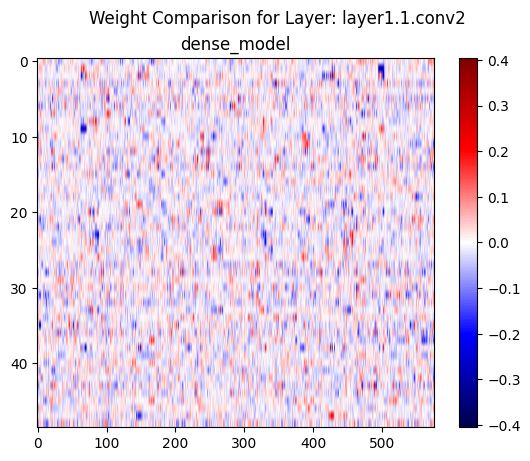

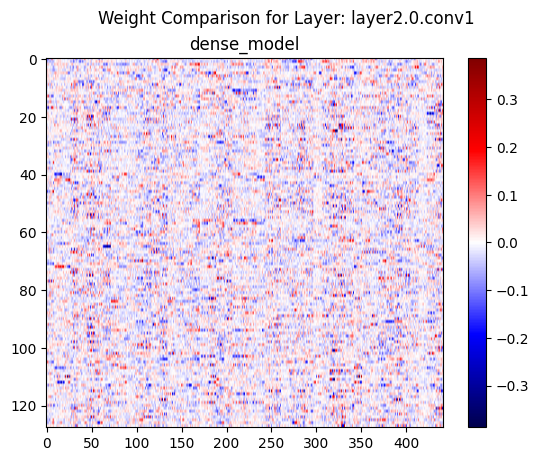

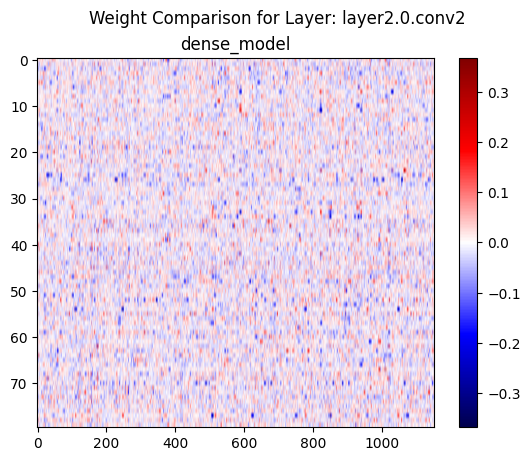

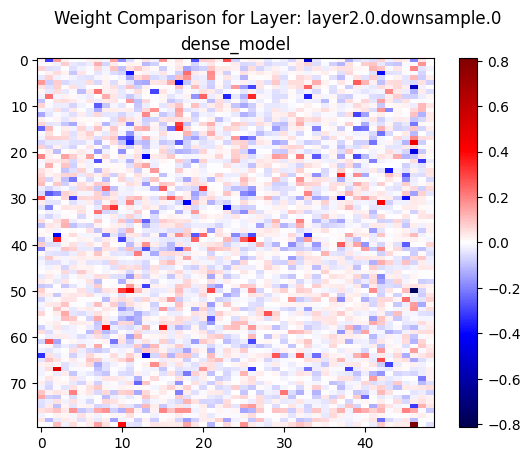

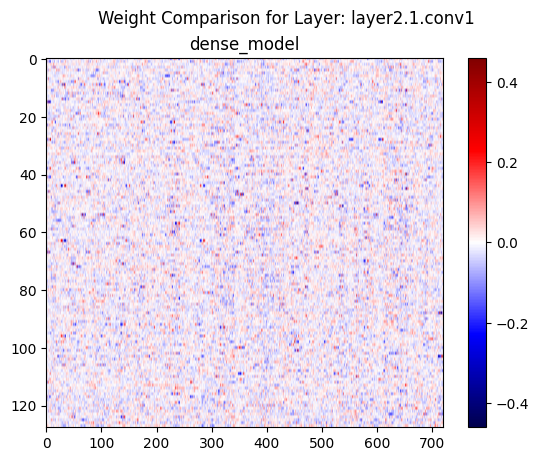

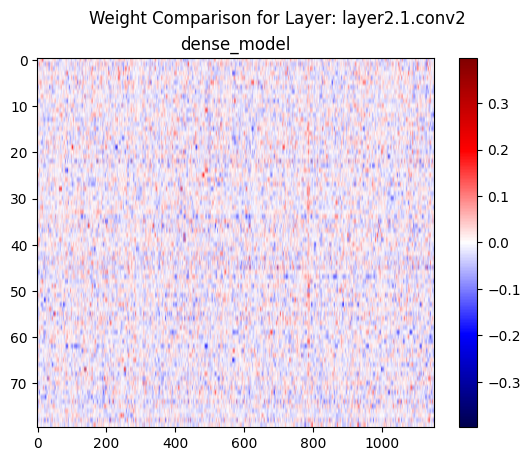

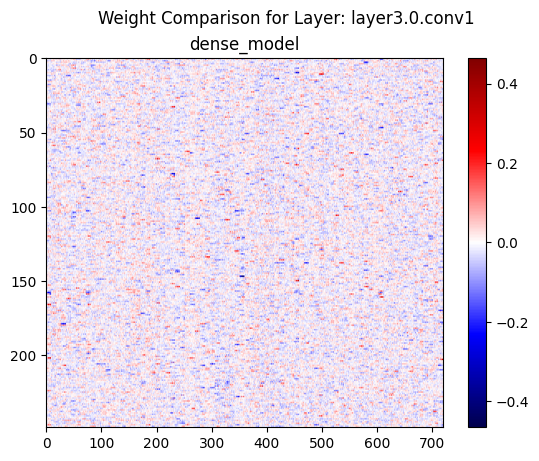

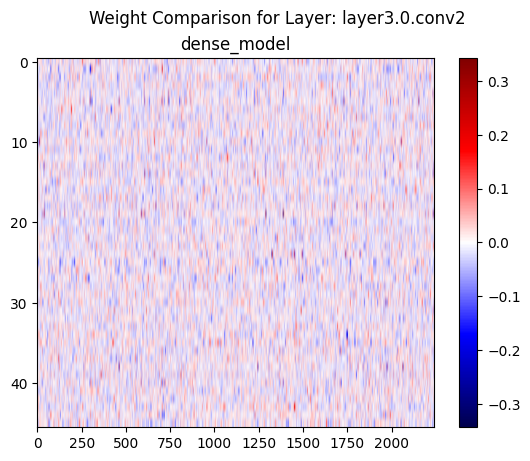

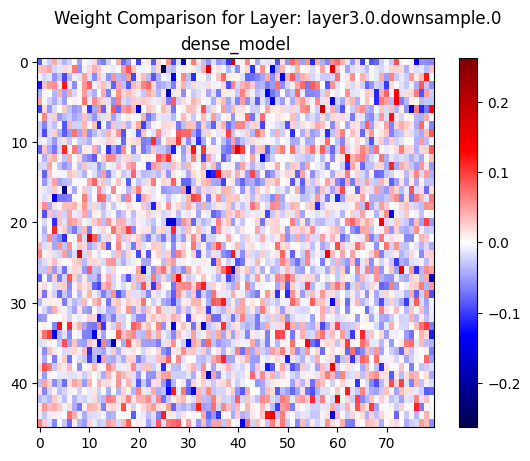

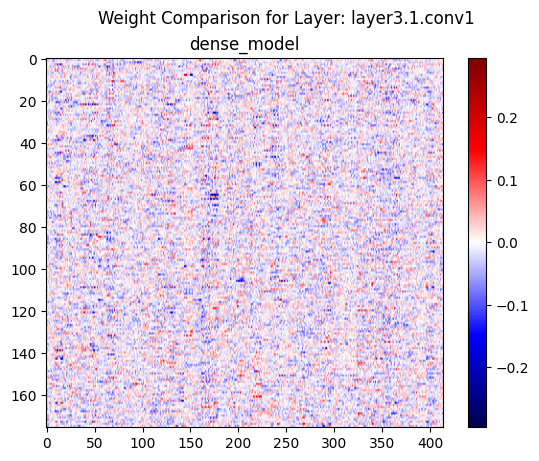

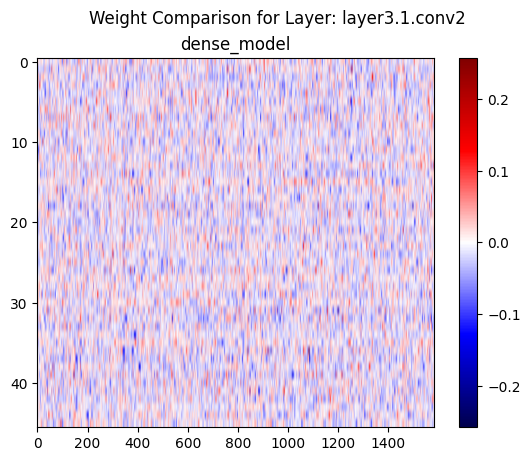

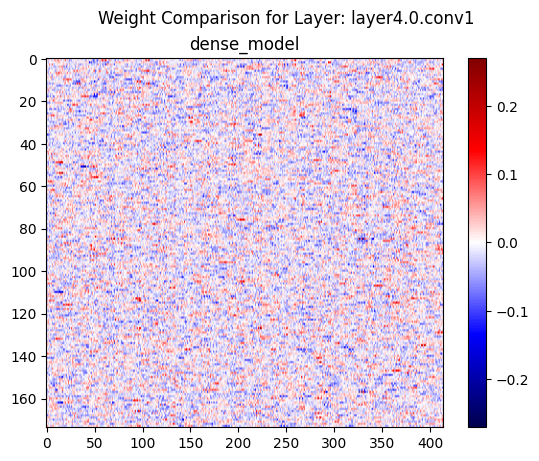

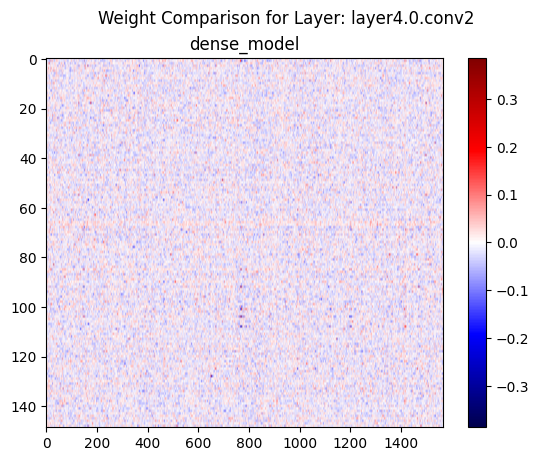

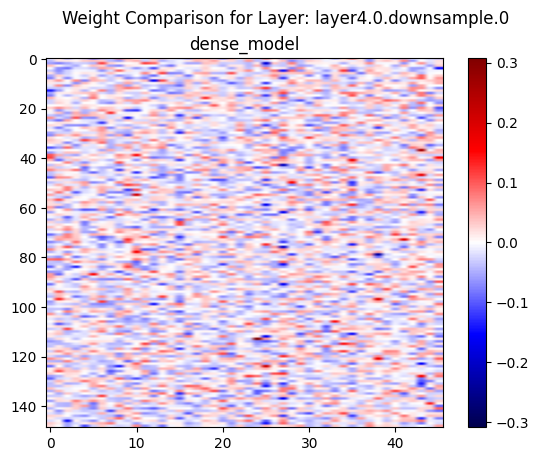

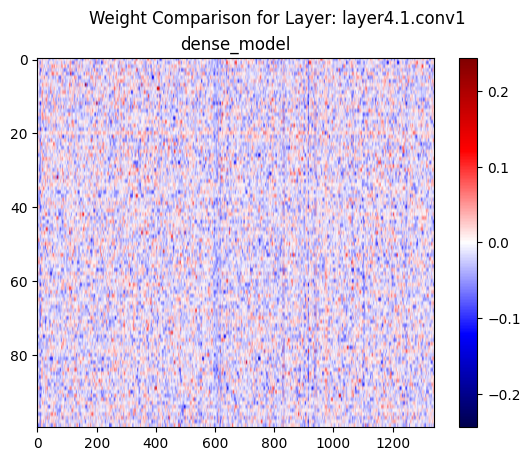

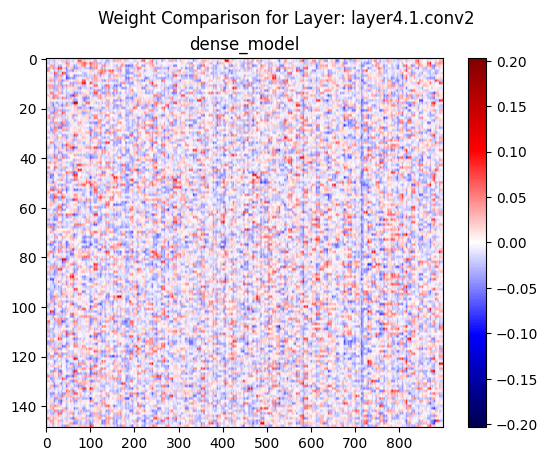

In [24]:
# 1. zipを使って2つのモデルのモジュールを同時にループ
model.to('cpu')
for (name1, module1) in model.named_modules():

    # 2. 両方のモジュールが畳み込み層(nn.Conv2d)か判定
    if isinstance(module1, nn.Conv2d):
        
        # グラフを2つ横に並べて表示する準備
        fig, axes = plt.subplots() # (1行, 2列)
        
        # --- 左側のグラフ (model1) ---
        w1_2d = module1.weight.data.view(module1.weight.size(0), -1).cpu().numpy()   #[:64, :147]      
        
        # 3. カラーマップの範囲を両モデルで揃える（重要！）
        # これにより、色の濃淡を公平に比較できる
        vmax = np.abs(w1_2d).max()
        
        # model1の重みをプロット
        im1 = axes.imshow(w1_2d, cmap='seismic', aspect='auto', vmin=-vmax, vmax=vmax)
        axes.set_title("dense_model")

        # カラーバーを追加
        fig.colorbar(im1, ax=axes)
        
        # グラフ全体にタイトルを付ける
        fig.suptitle(f'Weight Comparison for Layer: {name1}')
        
        plt.show()